# 06 — Explainability (SHAP) + GenAI Retention Advisor

A churn score alone isn't actionable — retention teams need to know **why** each
customer is at risk and **what to do**. Two layers:

1. **SHAP (TreeExplainer)** — exact per-customer attributions for the tuned LightGBM.
2. **GenAI advisor** (`src/genai/advisor.py`) — Gemini turns each customer's SHAP
   drivers into a structured retention plan (JSON), with a **rule-based fallback** so
   the system works offline and never returns nothing.

> SHAP runs on the uncalibrated pipeline: isotonic calibration is monotonic, so risk
> *rankings* and attributions are unchanged — calibration fixes probabilities, SHAP
> explains drivers.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

ROOT = Path.cwd()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
FIG = ROOT / "reports" / "figures"

from src.models.explain import ChurnExplainer
from src.genai.advisor import advise

ex = ChurnExplainer()
df = pd.read_parquet(ROOT / "data" / "processed" / "churn_features.parquet")
X = df.drop(columns=["churn", "customer_id"])
print("explainer ready,", len(ex.feature_names), "encoded features")

C:\Users\srira\.venvs\churn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


explainer ready, 54 encoded features


## 1. Global view — what drives churn across the book?

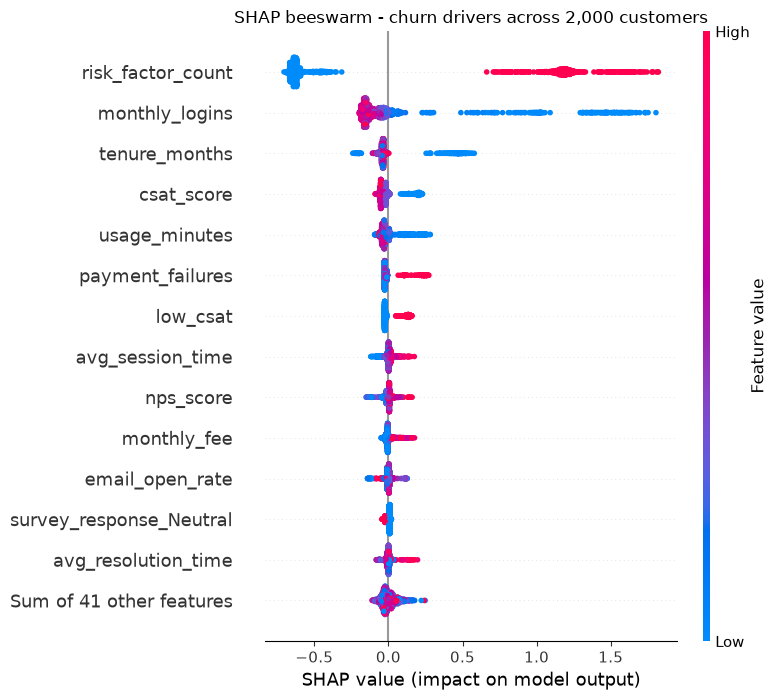

In [2]:
sample = X.sample(2000, random_state=42)
exp = ex.explanation(sample)

fig = plt.figure(figsize=(9, 7))
shap.plots.beeswarm(exp, max_display=14, show=False)
plt.title("SHAP beeswarm - churn drivers across 2,000 customers")
plt.tight_layout()
plt.savefig(FIG / "13_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** `risk_factor_count` — the compound flag engineered in Phase 4 — dominates
(mean |SHAP| ≈ 0.82, 4× the runner-up). High counts (red, right side) push strongly
toward churn. Behind it: `monthly_logins`, `tenure_months`, `csat_score`,
`payment_failures` — exactly the four statistically-validated drivers.

Two lessons worth stating in an interview:
- **Feature engineering became the model's backbone** — the model prefers our compound
  risk flag over any raw column.
- Phase 4's split-count importances *buried* the flags (a binary feature can only split
  once per path); SHAP reverses that verdict. Choosing the right attribution method
  changes the story.

## 2. Local view — why is *this* customer at risk?

C:\Users\srira\.venvs\churn\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


customer #7754: churn probability 48.6%


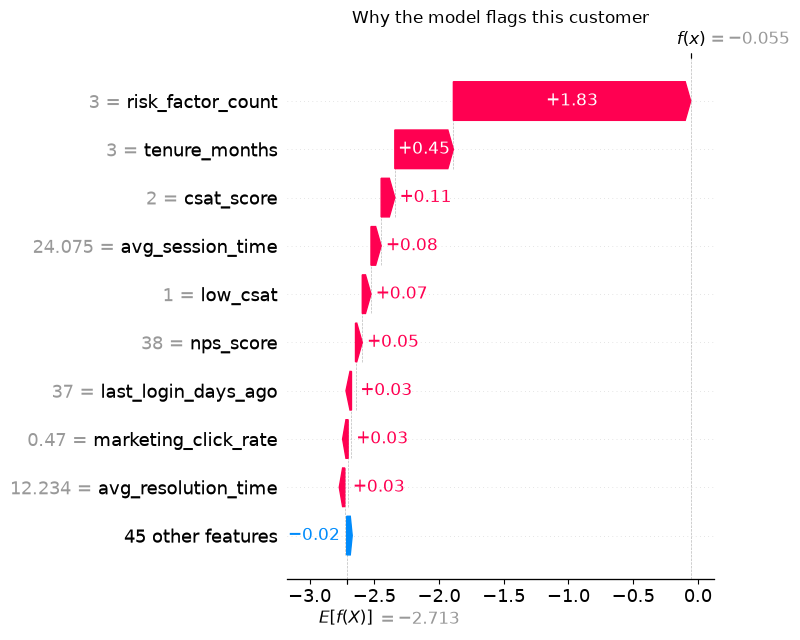

[{'feature': 'risk_factor_count',
  'value': 3.0,
  'shap': 1.8337,
  'direction': 'pushes toward churn'},
 {'feature': 'tenure_months',
  'value': 3.0,
  'shap': 0.4522,
  'direction': 'pushes toward churn'},
 {'feature': 'csat_score',
  'value': 2.0,
  'shap': 0.1056,
  'direction': 'pushes toward churn'},
 {'feature': 'avg_session_time',
  'value': 24.075,
  'shap': 0.0785,
  'direction': 'pushes toward churn'},
 {'feature': 'low_csat',
  'value': 1.0,
  'shap': 0.0673,
  'direction': 'pushes toward churn'}]

In [3]:
proba_all = ex.pipeline.predict_proba(X)[:, 1]
riskiest = int(np.argmax(proba_all))
row = X.iloc[[riskiest]]
print(f"customer #{riskiest}: churn probability {proba_all[riskiest]:.1%}")

exp_one = ex.explanation(row)
fig = plt.figure(figsize=(9, 5))
shap.plots.waterfall(exp_one[0], max_display=10, show=False)
plt.title("Why the model flags this customer")
plt.tight_layout()
plt.savefig(FIG / "14_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

ex.top_drivers(row, k=5)

**Read:** the waterfall decomposes one prediction into additive contributions — the
same `top_drivers()` output feeds the GenAI layer below. This is the bridge from model
to action: score → drivers → plan.

## 3. GenAI advisor — from drivers to a retention plan

`advise()` sends the profile + SHAP drivers to **Gemini** (model in `config.yaml`, key
in `.env`) with a JSON-only contract: risk level, plain-English drivers, and actions
each grounded in a driver. Without a key or on API failure it falls back to
**rule-based** plans built from the Phase 2/3 findings — the `source` field always
tells you which path produced the plan.

In [4]:
profile_cols = ["customer_segment", "tenure_months", "monthly_fee", "csat_score",
                "payment_failures", "last_login_days_ago", "monthly_logins"]

top3 = np.argsort(-proba_all)[:3]
for i in top3:
    row = X.iloc[[int(i)]]
    customer = {c: (v.item() if hasattr(v := row.iloc[0][c], "item") else str(v))
                for c in profile_cols}
    plan = advise(customer, ex.top_drivers(row), float(proba_all[i]))
    print(f"{'='*70}")
    print(f"customer #{i} - churn probability {proba_all[i]:.0%}")
    print(json.dumps(plan, indent=2))

customer #7754 - churn probability 49%
{
  "risk_level": "high",
  "summary": "Customer with 49% churn probability; 3 driver-matched retention action(s) proposed.",
  "drivers_plain_english": [
    "Multiple independent risk flags are active at once (risk_factor_count=3.0)",
    "Customer is early in their lifecycle (tenure_months=3.0)",
    "Recent support experience left the customer dissatisfied (csat_score=2.0)"
  ],
  "recommended_actions": [
    {
      "action": "Escalate to a human retention specialist for a save call",
      "rationale": "Compound risk (e.g. low CSAT + payment issues) reaches 37% churn"
    },
    {
      "action": "Enroll in guided onboarding with a success-milestone check-in",
      "rationale": "Churn hazard is concentrated in early tenure"
    },
    {
      "action": "Priority callback from senior support + goodwill credit",
      "rationale": "CSAT <= 2 customers churn at 24-26% vs 10% baseline"
    }
  ],
  "source": "rule-based fallback (no GEMINI_API_

**Read:** every recommended action traces back to a SHAP driver, which traces back to
a statistically-validated finding — no hallucinated advice. The retention team gets a
prioritized, explainable work queue instead of a bare score.

---
## What Phase 6 added

| Layer | Artifact |
|---|---|
| Exact attributions | `src/models/explain.py` (`ChurnExplainer`) |
| Global + local plots | beeswarm, waterfall (`reports/figures/`) |
| GenAI advisor | `src/genai/advisor.py` — Gemini + rule-based fallback, JSON contract |
| Guarantees | offline-safe, action ⊆ drivers, tested (`tests/test_advisor.py`) |

Phase 7 wraps this into a FastAPI service (`/predict` → score + drivers + plan) and a
Streamlit dashboard.